# Week 1 exercises

## Ex 1

### Part 1

#### a)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [ ]:
def LCG(x0: int, a: int, c: int, M:int, num_iters: int):        
    U = [x0]
    for _ in range(num_iters):
        x0 = (a*x0+c)%M
        U.append(x0)
    return np.array(U)/M


In [ ]:
x0 = 42 # seed
M = 2**31-1
a = 16807
c = 0
num_iters = 10000
U = LCG(x0,a,c,M,num_iters)


plt.hist(U, bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of U')
plt.xlabel('U')
plt.ylabel("Count")
plt.plot()

#### b)

In [ ]:
# Scatter plot: U_i vs U_{i+1}
plt.scatter(U[:-1], U[1:], s=1, alpha=0.5)
plt.title('Scatter plot of $U_i$ vs $U_{i+1}$')
plt.xlabel('$U_i$')
plt.ylabel('$U_{i+1}$')
plt.tight_layout()
plt.show()

In [ ]:
# chi-square test
classes = 10
observed, _ = np.histogram(U,classes)
expected_class = 10000/classes
T = np.sum((observed-expected_class)**2/expected_class)
critical_value = 16.919 # Formula collection with classes-1=9 dof freedom at 95% confidence level.

if T<critical_value:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")

# Calculate p-value
p_val = stats.chi2.sf(T, classes - 1)

print(f"Chi-square statistic: {T:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")


In [ ]:
# Kolmogorov-Smirnov test
observed_cdf = np.cumsum(observed)/len(U)
theoretical_cdf = np.cumsum([expected_class]*10)/len(U)

D = np.max(np.abs(observed_cdf - theoretical_cdf))

adjusted_D = (np.sqrt(len(U))+0.12 + 0.11/np.sqrt(len(U)))*D
if adjusted_D < 1.358: 
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")

# Calculate p-value
p_val = stats.kstwobign.sf(adjusted_D)

print(f"Adjusted D statistic: {adjusted_D:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")


In [ ]:
# run test I
median_U = np.median(U)

runs = np.array([1 if x > median_U else -1 for x in U if x != median_U])

n1 = np.sum(runs == 1)
n2 = np.sum(runs == -1)

num_runs = 1
for i in range(1, len(runs)):
    if runs[i] != runs[i-1]:
        num_runs += 1

n = n1 + n2
expected_runs = (2 * n1 * n2) / n + 1
var_runs = (2 * n1 * n2 * (2 * n1 * n2 - n)) / ((n ** 2) * (n - 1))

Z_runs = (num_runs - expected_runs) / np.sqrt(var_runs)

print(f"Number of runs: {num_runs}")
print(f"Expected runs: {expected_runs:.2f}")
print(f"Z-statistic: {Z_runs:.4f}")

# Critical value for 95% confidence level is 1.96
if np.abs(Z_runs) < 1.96:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")


# Calculate two-sided p-value
p_val = 2 * stats.norm.sf(abs(Z_runs))

print(f"Number of runs: {num_runs}")
print(f"Expected runs: {expected_runs:.2f}")
print(f"Z-statistic: {Z_runs:.4f}, p-value: {p_val:.4f}")

if p_val > 0.05:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")



In [ ]:
# run-test II
runs = 1
run_lengths = []
run_length = 1

for i in range(1, len(U)):
    if U[i] < U[i-1]:
        runs += 1
        run_lengths.append(run_length)
        run_length = 1
    else:
        run_length += 1

run_lengths.append(run_length)

from collections import Counter

run_lengths_bunched = [6 if length >= 6 else length for length in run_lengths]
run_length_counts = Counter(run_lengths_bunched)
run_length_counts = dict(sorted(run_length_counts.items()))
R = np.array([run_length_counts.get(i, 0) for i in range(1, 7)])
A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
])
B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

Z = 1 / (len(U)-6)*(R-len(U)*B).T@A@(R-len(U)*B)

if Z < 12.592:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")

# Calculate p-value
p_val = stats.chi2.sf(Z, 6)

print(f"Z-statistic for run-test II: {Z:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")


In [ ]:
# correlation test

h = 4

c = (1 / (len(U) - h)) * sum(U[i] * U[i + h] for i in range(len(U) - h))

expected_mean = 0.25
variance = 7 / (144 * len(U))
std_dev = np.sqrt(variance)

Z = (c - expected_mean) / std_dev

critical_value = 1.96  # for alpha = 0.05

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")


# Calculate two-sided p-value
p_val = 2 * stats.norm.sf(abs(Z))

print(f"Z-statistic for correlation test: {Z:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")


#### c)

In [ ]:
x0 = 42 # seed
M = 2**16-1
a = 100
c = 5
num_iters = 10000
U = LCG(x0,a,c,M,num_iters)


plt.hist(U, bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of U')
plt.xlabel('U')
plt.ylabel("Count")
plt.plot()

In [ ]:
# Scatter plot: U_i vs U_{i+1}
plt.scatter(U[:-1], U[1:], s=1, alpha=0.5)
plt.title('Scatter plot of $U_i$ vs $U_{i+1}$')
plt.xlabel('$U_i$')
plt.ylabel('$U_{i+1}$')
plt.tight_layout()
plt.show()

In [ ]:
# chi-square test
classes = 10
observed, _ = np.histogram(U,classes)
expected_class = 10000/classes
T = np.sum((observed-expected_class)**2/expected_class)
critical_value = 16.919 # Formula collection with classes-1=9 dof freedom at 95% confidence level.

print(f"Chi-square statistic: {T:.4f}")
if T<critical_value:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")


# Calculate p-value
p_val = stats.chi2.sf(T, classes - 1)

print(f"Chi-square statistic: {T:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")



In [ ]:
# Kolmogorov-Smirnov test
observed_cdf = np.cumsum(observed)/len(U)
theoretical_cdf = np.cumsum([expected_class]*10)/len(U)

D = np.max(np.abs(observed_cdf - theoretical_cdf))

adjusted_D = (np.sqrt(len(U))+0.12 + 0.11/np.sqrt(len(U)))*D
print(f"Adjusted D statistic for Kolmogorov-Smirnov test: {adjusted_D:.4f}")
if adjusted_D < 1.358: 
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")

# Calculate p-value
p_val = stats.kstwobign.sf(adjusted_D)

print(f"Adjusted D statistic: {adjusted_D:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")


In [ ]:
# run test I
median_U = np.median(U)

runs = np.array([1 if x > median_U else -1 for x in U if x != median_U])

n1 = np.sum(runs == 1)
n2 = np.sum(runs == -1)

num_runs = 1
for i in range(1, len(runs)):
    if runs[i] != runs[i-1]:
        num_runs += 1

n = n1 + n2
expected_runs = (2 * n1 * n2) / n + 1
var_runs = (2 * n1 * n2 * (2 * n1 * n2 - n)) / ((n ** 2) * (n - 1))

Z_runs = (num_runs - expected_runs) / np.sqrt(var_runs)

print(f"Number of runs: {num_runs}")
print(f"Expected runs: {expected_runs:.2f}")
print(f"Z-statistic: {Z_runs:.4f}")

# Critical value for 95% confidence level is 1.96
if np.abs(Z_runs) < 1.96:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")

# Calculate two-sided p-value
p_val = 2 * stats.norm.sf(abs(Z_runs))

print(f"Number of runs: {num_runs}")
print(f"Expected runs: {expected_runs:.2f}")
print(f"Z-statistic: {Z_runs:.4f}, p-value: {p_val:.4f}")

if p_val > 0.05:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")



In [ ]:
# run-test II
runs = 1
run_lengths = []
run_length = 1

for i in range(1, len(U)):
    if U[i] < U[i-1]:
        runs += 1
        run_lengths.append(run_length)
        run_length = 1
    else:
        run_length += 1

run_lengths.append(run_length)

from collections import Counter

run_lengths_bunched = [6 if length >= 6 else length for length in run_lengths]
run_length_counts = Counter(run_lengths_bunched)
run_length_counts = dict(sorted(run_length_counts.items()))
R = np.array([run_length_counts.get(i, 0) for i in range(1, 7)])
A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
])
B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

Z = 1 / (len(U)-6)*(R-len(U)*B).T@A@(R-len(U)*B)

print(f"Z-statistic for run-test II: {Z:.4f}")

if Z < 12.592:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")

# Calculate p-value
p_val = stats.chi2.sf(Z, 6)

print(f"Z-statistic for run-test II: {Z:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")


In [ ]:
# correlation test

h = 4

c = (1 / (len(U) - h)) * sum(U[i] * U[i + h] for i in range(len(U) - h))

expected_mean = 0.25
variance = 7 / (144 * len(U))
std_dev = np.sqrt(variance)

Z = (c - expected_mean) / std_dev

print(f"Z-statistic for correlation test: {Z:.4f}")

critical_value = 1.96  # for alpha = 0.05

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")

# Calculate two-sided p-value
p_val = 2 * stats.norm.sf(abs(Z))

print(f"Z-statistic for correlation test: {Z:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")



### part 2

In [ ]:
np.random.seed(42)
U = np.random.uniform(0, 1, 10001)


plt.hist(U, bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of U')
plt.xlabel('U')
plt.ylabel("Count")
plt.plot()

In [ ]:
# Scatter plot: U_i vs U_{i+1}
plt.scatter(U[:-1], U[1:], s=1, alpha=0.5)
plt.title('Scatter plot of $U_i$ vs $U_{i+1}$')
plt.xlabel('$U_i$')
plt.ylabel('$U_{i+1}$')
plt.tight_layout()
plt.show()

In [ ]:
# chi-square test
classes = 10
observed, _ = np.histogram(U,classes)
expected_class = 10000/classes
T = np.sum((observed-expected_class)**2/expected_class)
critical_value = 16.919 # Formula collection with classes-1=9 dof freedom at 95% confidence level.

if T<critical_value:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")

# Calculate p-value
p_val = stats.chi2.sf(T, classes - 1)

print(f"Chi-square statistic: {T:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")


In [ ]:
# Kolmogorov-Smirnov test
observed_cdf = np.cumsum(observed)/len(U)
theoretical_cdf = np.cumsum([expected_class]*10)/len(U)

D = np.max(np.abs(observed_cdf - theoretical_cdf))

adjusted_D = (np.sqrt(len(U))+0.12 + 0.11/np.sqrt(len(U)))*D
if adjusted_D < 1.358: 
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")

# Calculate p-value
p_val = stats.kstwobign.sf(adjusted_D)

print(f"Adjusted D statistic: {adjusted_D:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of uniform distribution cannot be rejected.")
else:
    print("The null hypothesis of uniform distribution is rejected.")


In [ ]:
# run test I
median_U = np.median(U)

runs = np.array([1 if x > median_U else -1 for x in U if x != median_U])

n1 = np.sum(runs == 1)
n2 = np.sum(runs == -1)

num_runs = 1
for i in range(1, len(runs)):
    if runs[i] != runs[i-1]:
        num_runs += 1

n = n1 + n2
expected_runs = (2 * n1 * n2) / n + 1
var_runs = (2 * n1 * n2 * (2 * n1 * n2 - n)) / ((n ** 2) * (n - 1))

Z_runs = (num_runs - expected_runs) / np.sqrt(var_runs)

print(f"Number of runs: {num_runs}")
print(f"Expected runs: {expected_runs:.2f}")
print(f"Z-statistic: {Z_runs:.4f}")

# Critical value for 95% confidence level is 1.96
if np.abs(Z_runs) < 1.96:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")

# Calculate two-sided p-value
p_val = 2 * stats.norm.sf(abs(Z_runs))

print(f"Number of runs: {num_runs}")
print(f"Expected runs: {expected_runs:.2f}")
print(f"Z-statistic: {Z_runs:.4f}, p-value: {p_val:.4f}")

if p_val > 0.05:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")


In [ ]:
# run-test II
runs = 1
run_lengths = []
run_length = 1

for i in range(1, len(U)):
    if U[i] < U[i-1]:
        runs += 1
        run_lengths.append(run_length)
        run_length = 1
    else:
        run_length += 1

run_lengths.append(run_length)

from collections import Counter

run_lengths_bunched = [6 if length >= 6 else length for length in run_lengths]
run_length_counts = Counter(run_lengths_bunched)
run_length_counts = dict(sorted(run_length_counts.items()))
R = np.array([run_length_counts.get(i, 0) for i in range(1, 7)])
A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
])
B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

Z = 1 / (len(U)-6)*(R-len(U)*B).T@A@(R-len(U)*B)

if Z < 12.592:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")

# Calculate p-value
p_val = stats.chi2.sf(Z, 6)

print(f"Z-statistic for run-test II: {Z:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("The null hypothesis of independence cannot be rejected.")
else:
    print("The null hypothesis of independence is rejected.")


In [ ]:
# correlation test

h = 4

c = (1 / (len(U) - h)) * sum(U[i] * U[i + h] for i in range(len(U) - h))

expected_mean = 0.25
variance = 7 / (144 * len(U))
std_dev = np.sqrt(variance)

Z = (c - expected_mean) / std_dev

critical_value = 1.96  # for alpha = 0.05

if abs(Z) < critical_value:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")

# Calculate two-sided p-value
p_val = 2 * stats.norm.sf(abs(Z))

print(f"Z-statistic for correlation test: {Z:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("Fail to reject H0: No significant evidence of correlation (behaves like true white noise).")
else:
    print("Reject H0: Significant evidence of correlation (the random number generator has a defect).")



### part 3

In [ ]:
x0 = 42 # seed
M = 2**31-1
a = 16807
c = 0
num_iters = 10000
U_100 = []
for i in range(100):
    U = LCG(x0, a, c, M, num_iters)
    U_100.append(U)
    # Use the last generated integer as the correct seed for the next sequence!
    x0 = int(U[-1] * M) 

plt.hist(U_100[0], bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of $U_{100}[0]$')
plt.show()

In [ ]:
# Scatter plot: U_i vs U_{i+1}
plt.scatter(U_100[0][:-1], U_100[0][1:], s=1, alpha=0.5)
plt.title('Scatter plot of $U_i$ vs $U_{i+1}$ for $U_{100}[0]$')
plt.xlabel('$U_i$')
plt.ylabel('$U_{i+1}$')
plt.tight_layout()
plt.show()

In [ ]:
# chi-square test
classes = 10
critical_value = 16.919

reject_count = 0
for U in U_100:
    observed, _ = np.histogram(U, classes)
    expected_class = len(U) / classes
    T = np.sum((observed - expected_class)**2 / expected_class)
    

    # Calculate p-value
    p_val = stats.chi2.sf(T, classes - 1)

    if p_val <= 0.05:
        reject_count += 1

print(f"Chi-Square Test: H0 rejected {reject_count} times out of 100.")

In [ ]:
# Kolmogorov-Smirnov test
classes = 10
reject_count = 0

for U in U_100:
    observed, _ = np.histogram(U, classes)
    expected_class = len(U) / classes
    
    observed_cdf = np.cumsum(observed) / len(U)
    theoretical_cdf = np.cumsum([expected_class] * classes) / len(U)
    
    D = np.max(np.abs(observed_cdf - theoretical_cdf))
    
    adjusted_D = (np.sqrt(len(U)) + 0.12 + 0.11 / np.sqrt(len(U))) * D
    
    # Calculate p-value
    p_val = stats.kstwobign.sf(adjusted_D)

    if p_val <=0.05: 
        reject_count += 1

print(f"KS Test: H0 rejected {reject_count} times out of 100.")

In [ ]:
# run test I
reject_count = 0

for U in U_100:
    median_U = np.median(U)
    runs_arr = np.array([1 if x > median_U else -1 for x in U if x != median_U])
    
    n1 = np.sum(runs_arr == 1)
    n2 = np.sum(runs_arr == -1)
    num_runs = 1
    for i in range(1, len(runs_arr)):
        if runs_arr[i] != runs_arr[i-1]:
            num_runs += 1
            
    n = n1 + n2
    expected_runs = (2 * n1 * n2) / n + 1
    var_runs = (2 * n1 * n2 * (2 * n1 * n2 - n)) / ((n ** 2) * (n - 1))
    Z_runs = (num_runs - expected_runs) / np.sqrt(var_runs)
    
    # Calculate two-sided p-value
    p_val = 2 * stats.norm.sf(abs(Z_runs))


    if p_val <= 0.05:
        reject_count += 1

print(f"Run-Test I: H0 rejected {reject_count} times out of 100.")

In [ ]:
# run-test II
from collections import Counter
reject_count = 0

A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]
])
B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

for U in U_100:
    run_lengths = []
    run_length = 1
    for i in range(1, len(U)):
        if U[i] < U[i-1]:
            run_lengths.append(run_length)
            run_length = 1
        else:
            run_length += 1
    run_lengths.append(run_length)

    run_lengths_bunched = [6 if length >= 6 else length for length in run_lengths]
    run_length_counts = Counter(run_lengths_bunched)
    R = np.array([run_length_counts.get(i, 0) for i in range(1, 7)])

    Z = 1 / len(U) * (R - len(U) * B).T @ A @ (R - len(U) * B)

    # Calculate p-value
    p_val = stats.chi2.sf(Z, 6)

    if p_val <= 0.05:
        reject_count += 1

print(f"Run-Test II: H0 rejected {reject_count} times out of 100.")

In [ ]:
# correlation test
h = 4
expected_mean = 0.25
critical_value = 1.96  

reject_count = 0
for U in U_100:
    variance = 7 / (144 * len(U))
    std_dev = np.sqrt(variance)
    
    c = (1 / (len(U) - h)) * sum(U[i] * U[i + h] for i in range(len(U) - h))
    Z = (c - expected_mean) / std_dev
    
    # Calculate two-sided p-value
    p_val = 2 * stats.norm.sf(abs(Z))

    if p_val <= 0.05:
        reject_count += 1
        
print(f"Correlation Test (h={h}): H0 rejected {reject_count} times out of 100.")

## Ex 2

### Part 1

To generate observations from the geometric distribution, we can use the direct (crude) method via inverse transformation. A random variable $X \sim \text{Geometric}(p)$ models the number of trials up to and including the first success. Its cumulative distribution function (CDF) is $F(n) = 1 - (1 - p)^n$. By generating a standard uniform random variable $U \sim U(0, 1)$ and setting $X = n$ if $F(n - 1) < U \leq F(n)$, we can derive the generator equation: 

$$X = \left\lfloor \frac{\log(U)}{\log(1 - p)} \right\rfloor + 1$$

In this cell, we will define a function to simulate this, compare the simulated data against the theoretical distribution using histograms, and apply a Chi-Square goodness-of-fit test for small ($p=0.1$), moderate ($p=0.5$), and large ($p=0.9$) values of $p$.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)
N = 10000


# Test for small, moderate, and large p
p_values = [0.1, 0.5, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, p in enumerate(p_values):
    # 1. Simulate 10,000 observations
    simulated_data = np.random.geometric(p, N)

    # 2. Get unique values and their empirical frequencies
    values, counts = np.unique(simulated_data, return_counts=True)
    empirical_probs = counts / N
    
    # 3. Calculate theoretical probabilities for the observed values
    theoretical_probs = p * (1 - p)**(values - 1)
    
    # 4. Chi-Square Test
    expected_counts = theoretical_probs * N
    
    # Normalize expected counts so their sum matches the sum of observed counts exactly
    expected_counts = expected_counts * (np.sum(counts) / np.sum(expected_counts))
    
    # (Simplified chi-square for demonstration; avoiding bins with 0 expected counts)
    chi2_stat, p_val = stats.chisquare(f_obs=counts, f_exp=expected_counts)
    
    # Plotting
    ax = axes[i]
    ax.bar(values - 0.2, empirical_probs, width=0.4, label='Simulated', alpha=0.7)
    ax.bar(values + 0.2, theoretical_probs, width=0.4, label='Theoretical', alpha=0.7)
    ax.set_title(f"Geometric(p={p})\nChi2 p-value: {p_val:.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("Probability")
    ax.set_xlim(0, max(values) + 1)
    ax.legend()

plt.tight_layout()
plt.show()

### Part 2

We are given a discrete distribution over $x_i \in \{1, 2, 3, 4, 5, 6\}$ with probabilities $p_i \propto \left[\frac{7}{48}, \frac{5}{48}, \frac{1}{8}, \frac{1}{16}, \frac{1}{4}, \frac{5}{16}\right]$. Note that these initial values sum to $1$, so they already constitute a valid probability mass function (PMF). Converting them to a common denominator of 48 makes the exact probabilities clearer: $p = \left[\frac{7}{48}, \frac{5}{48}, \frac{6}{48}, \frac{3}{48}, \frac{12}{48}, \frac{15}{48}\right]$. 

We will implement three specific generation methods:

* **Direct (Crude) Method:** Uses the cumulative distribution function (CDF) $F(x_k)$. We generate $U \sim U(0,1)$ and perform a search to find $x_i$ such that $F(x_{i-1}) < U \leq F(x_i)$.
* **Rejection Method:** We sample from a uniform proposal distribution $Y \in \{1, \dots, 6\}$ with $q_i = 1/6$. We must choose a constant $c$ such that $c \geq \max(p_i / q_i)$. The maximum $p_i$ is $15/48$, so $c = 6 \times (15/48) = 90/48 = 1.875$. We generate $Y$ and $U \sim U(0,1)$, then accept $Y$ if $U \leq \frac{p_Y}{c q_Y}$.
* **Alias Method:** We decompose the distribution into an equally weighted mixture of $n=6$ distributions, each having at most two outcomes (an original value and an "alias"). This requires an initial setup step but allows sampling with exactly one uniform variable, one comparison, and a table lookup.


In [ ]:
np.random.seed(42)
# Setup the distribution
xi = np.array([1, 2, 3, 4, 5, 6])
pi = np.array([7/48, 5/48, 6/48, 3/48, 12/48, 15/48])

# ==========================================
# 1. Direct (Crude) Method
# ==========================================
def generate_direct(size):
    P = np.cumsum(pi)
    U = np.random.rand(size)
    samples = np.zeros(size, dtype=int)
    
    P_prev = 0.0
    for i in range(len(pi)):
        mask = (U > P_prev) & (U <= P[i])
        samples[mask] = xi[i]
        P_prev = P[i]
        
    return samples

# ==========================================
# 2. Simple Rejection Method
# ==========================================
def generate_rejection(size):
    k = len(xi)
    c = np.max(pi)+0.01
    
    # Generate proposal candidates. Use more so that we have "size" elements even if some fail. 
    U1 = np.random.rand(size*3)
    U2 = np.random.rand(size*3)
    
    # 1. Generate proposal indices
    I = np.floor(k * U1).astype(int)
    
    # 2. Acceptance condition
    p_I = pi[I]
    accepted_mask = U2 <= (p_I / c)
    
    accepted_samples = xi[I[accepted_mask]]
    

    return accepted_samples[:size]


# ==========================================
# 3. Alias Method
# ==========================================
def setup_alias(probs):
    """Pre-computes the alias and probability tables explicitly."""
    K = len(probs)
    F = np.zeros(K)
    L = np.zeros(K, dtype=int)
    
    smaller = []
    larger = []
    scaled_probs = probs * K
    
    for i, prob in enumerate(scaled_probs):
        if prob < 1.0: 
            smaller.append(i)
        else: 
            larger.append(i)
            
    while smaller and larger:
        small = smaller.pop()
        large = larger.pop()
        
        L[small] = large
        F[small] = scaled_probs[small]
        scaled_probs[large] = scaled_probs[large] - (1.0 - scaled_probs[small])
        
        if scaled_probs[large] < 1.0:
            smaller.append(large)
        else: 
            larger.append(large)
            
    while larger: 
        F[larger.pop()] = 1.0
    while smaller: 
        F[smaller.pop()] = 1.0
        
    return F, L

def generate_alias(size, F, L):
    K = len(F)
    U1 = np.random.rand(size)
    U2 = np.random.rand(size)
    
    # 1. Select random bin: I = floor(K * U1)
    I = np.floor(K * U1).astype(int)
    
    # 2. Coin toss comparison: U2 <= q_I
    use_original = U2 <= F[I]
    
    # 3. Output original value or alias
    indices = np.where(use_original, I, L[I])
    return xi[indices]

# Setup Alias tables once
F_table, L_table = setup_alias(pi)

# Generate 10,000 observations to test validity
sim_direct = generate_direct(N)
sim_reject = generate_rejection(N)
sim_alias = generate_alias(N, F_table, L_table)

# plot
# Calculate empirical probabilities for each method
outcomes = np.arange(1, 7)
empirical_direct = np.array([np.sum(sim_direct == x) / N for x in outcomes])
empirical_reject = np.array([np.sum(sim_reject == x) / N for x in outcomes])
empirical_alias = np.array([np.sum(sim_alias == x) / N for x in outcomes])

# Set bar widths
width = 0.18

plt.figure(figsize=(10, 6))

# Plot grouped bars
plt.bar(outcomes - 1.5 * width, pi, width, label='Theoretical', color='#2ca02c', alpha=0.85)
plt.bar(outcomes - 0.5 * width, empirical_direct, width, label='Direct (Crude)', color='#1f77b4', alpha=0.85)
plt.bar(outcomes + 0.5 * width, empirical_reject, width, label='Rejection', color='#ff7f0e', alpha=0.85)
plt.bar(outcomes + 1.5 * width, empirical_alias, width, label='Alias', color='#9467bd', alpha=0.85)

# Formatting the plot
plt.title("Comparison of Empirical vs. Theoretical Probabilities", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Outcome ($x_i$)", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.xticks(outcomes)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

### Part 3


To compare the methods, we will evaluate:
* Computational Efficiency: Measured by generating 100,000 samples and tracking execution time.
* Accuracy: Tested utilizing the Chi-Square test comparing generated counts to theoretical expected counts.
* Memory Requirements: Analyzed structurally.

In [ ]:
np.random.seed(42)
from time import perf_counter

size_benchmark = 100000
n_runs = 100

# Time Direct Method (Average over 100 runs)
times_direct = []
for _ in range(n_runs):
    start = perf_counter()
    generate_direct(size_benchmark)
    times_direct.append(perf_counter() - start)
time_direct = np.mean(times_direct)

# Time Rejection Method (Average over 100 runs)
times_rejection = []
for _ in range(n_runs):
    start = perf_counter()
    generate_rejection(size_benchmark)
    times_rejection.append(perf_counter() - start)
time_rejection = np.mean(times_rejection)

# Time Alias Method (Average over 100 runs)
times_alias = []
for _ in range(n_runs):
    start = perf_counter()
    # Note: we do not include the one-time setup cost in the generation loop for Alias
    generate_alias(size_benchmark, F_table, L_table)
    times_alias.append(perf_counter() - start)
time_alias = np.mean(times_alias)

print(f"--- Computational Efficiency (Average Time to generate 100,000 samples over {n_runs} runs) ---")
print(f"Direct Method:    {time_direct:.6f} seconds")
print(f"Rejection Method: {time_rejection:.6f} seconds")
print(f"Alias Method:     {time_alias:.6f} seconds")

print("\n--- Accuracy (Chi-Square Test p-values on 10,000 samples) ---")

def test_accuracy(simulated_data):
    counts = np.bincount(simulated_data)[1:] # Ignore 0 index
    expected_counts = pi * N
    stat, p_val = stats.chisquare(f_obs=counts, f_exp=expected_counts)
    return p_val

p_vals_direct = []
p_vals_reject = []
p_vals_alias = []

for _ in range(100):
    sim_direct = generate_direct(N)
    sim_reject = generate_rejection(N)
    sim_alias = generate_alias(N, F_table, L_table)
    p_vals_direct.append(test_accuracy(sim_direct))
    p_vals_reject.append(test_accuracy(sim_reject))
    p_vals_alias.append(test_accuracy(sim_alias))

p_val_direct = np.mean(p_vals_direct)
p_val_reject = np.mean(p_vals_reject)
p_val_alias = np.mean(p_vals_alias)

print(f"Direct Method p-value:    {p_val_direct:.4f}")
print(f"Rejection Method p-value: {p_val_reject:.4f}")
print(f"Alias Method p-value:     {p_val_alias:.4f}")

import sys

def get_memory(obj):
    if isinstance(obj, np.ndarray):
        return sys.getsizeof(obj) + obj.nbytes
    if isinstance(obj, list):
        return sys.getsizeof(obj) + sum(sys.getsizeof(i) for i in obj)
    return sys.getsizeof(obj)

direct_mem = get_memory(sim_direct)
rejection_mem = get_memory(sim_reject)

alias_samples_mem = get_memory(sim_alias)
alias_table_mem = get_memory(L_table) + get_memory(F_table) + get_memory(len(xi))
alias_total_mem = alias_samples_mem + alias_table_mem
print(f"\n--- Memory usage ---")
print(f"Direct method memory usage: {direct_mem} bytes")
print(f"Rejection method memory usage: {rejection_mem} bytes")
print(f"Alias method memory usage (samples only): {alias_samples_mem} bytes")
print(f"Alias table memory usage (L, F, k): {alias_table_mem} bytes")
print(f"Alias method total memory usage: {alias_total_mem} bytes")


### Part 4

Based on theoretical foundations and the results of our simulation experiments, we can evaluate each method based on its probabilistic mechanisms, statistical properties, speed, and memory requirements:

### 1. Direct (Crude) Method
* **Statistical Foundation:** Built upon the **Probability Integral Transform** (adapted for discrete random variables).
* **Probabilistic Mechanism:** It directly maps a continuous uniform random variable $U \sim U(0, 1)$ onto intervals partitioned by the cumulative distribution function (CDF), $F(x)$. Since the length of each interval $(F(x_{i-1}), F(x_i)]$ is exactly equal to the probability $p_i$, the probability that $U$ falls in that interval is exactly $p_i$.
* **Statistical Efficiency:** It has $100\%$ efficiency in terms of sample utilization—every generated uniform random variable directly translates to a sample from the target distribution.
* **Speed Analysis:** The generation speed is highly dependent on the support size $k$. Finding the matching interval requires a search algorithm: linear search takes $\mathcal{O}(k)$ time, while binary search takes $\mathcal{O}(\log k)$ time. As the number of outcomes $k$ grows large, the search process slows down.
* **Memory Analysis:** Excellent memory footprint. It only requires storing the cumulative probability array of size $k$.
* **Recommendation:** Prefer the direct method for simple distributions with a small number of outcomes, or in resource-constrained environments where preprocessing setup and extra memory overhead must be avoided.

### 2. Rejection Method
* **Statistical Foundation:** Based on the **Rejection Sampling Theorem**, which enables sampling from a target distribution $p_i$ using an easy-to-sample proposal distribution $q_i$.
* **Probabilistic Mechanism:** We propose a candidate state from $q_i$ (here, a discrete uniform distribution $q_i = 1/k$) and scale it by a constant $c$ to form an envelope $c \cdot q_i \ge p_i$. A Bernoulli trial accepts the proposal with probability $\frac{p_i}{c \cdot q_i}$, correcting the proposal bias and yielding samples from the true target distribution.
* **Statistical Efficiency:** The overall acceptance probability is exactly $1/c$ (in our case, $1/1.875 \approx 53.3\%$). While mathematically exact, it is sample-inefficient as nearly half of the generated variables are discarded.
* **Speed Analysis:** The speed is determined by the acceptance rate $1/c$. On average, we must generate $c$ uniform pairs to obtain a single accepted sample. While independent of the size of the distribution $k$, it can be slow if the proposal distribution is a poor fit for the target (i.e., when $c$ is large).
* **Memory Analysis:** Minimal memory footprint. It does not require any cumulative arrays or preprocessing tables; we only store the target probabilities and the constant $c$.
* **Recommendation:** Best suited when the CDF is analytically or computationally intractable, or when the target distribution is only known up to a normalizing constant (as the constant cancels out in the acceptance probability). It is most effective when the proposal distribution matches the target closely ($c \approx 1$).

### 3. Alias Method
* **Statistical Foundation:** Based on the theory of **Mixture Distributions** and the decomposition of probability mass functions.
* **Probabilistic Mechanism:** It decomposes the target $k$-outcome distribution into an equally weighted mixture of $k$ simpler distributions, where each sub-distribution has a support of at most two outcomes (an original value and an "alias"). Sampling is reduced to choosing a mixture component uniformly, followed by a simple Bernoulli trial (coin toss) to decide between the original value and its alias.
* **Statistical Efficiency:** It maintains $100\%$ efficiency (no rejected samples) while bypassing the need for a search algorithm, requiring only two independent uniform random numbers to resolve a sample.
* **Speed Analysis:** Generation runs in constant time $\mathcal{O}(1)$, independent of the size of the support $k$. Generating a sample requires only a uniform index lookup and a single comparison. This makes it by far the fastest generation method for large, complex distributions.
* **Memory Analysis:** High memory usage relative to the other methods. It requires a dedicated preprocessing step to create and store two separate lookup tables of size $k$ (the probability table $F$ and the alias index table $L$).
* **Recommendation:** Prefer the Alias method when generating a large number of random variables from a fixed, highly complex discrete distribution, where the upfront table setup cost is easily amortized by the constant-time sampling performance.

## Ex 3

### part 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats # pyrefly: ignore

# Set seed for reproducibility
np.random.seed(42)
N = 10000

# ==========================================
# (a) Exponential distribution (lambda = 1)
# ==========================================
U_exp = np.random.rand(N)
X_exp = -np.log(U_exp) # Formula: X = -(1/lambda)*log(U)
np.random.seed(42)
# ==========================================
# (b) Normal distribution (Box-Muller)
# ==========================================
U1,U2 = np.random.rand(2,N)
# Formula: Z1 = sqrt(-2*log(U1)) * cos(2*pi*U2)
X_norm = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)

np.random.seed(42)
# ==========================================
# (c) Pareto distribution (beta = 1, various k)
# ==========================================
beta = 1.0
k_values = [2.05, 2.5, 3.0, 4.0]
X_pareto = {}

for k in k_values:
    U_par = np.random.rand(N)
    # Formula: X = beta * U^(-1/k)
    X_pareto[k] = beta * (U_par ** (-1.0 / k))

# ==========================================
# Verification & Plots
# ==========================================
# Exp plot
plt.figure(figsize=(6, 4))
plt.hist(X_exp, bins=50, density=True, alpha=0.6, label="Simulated")
x_e = np.linspace(0, max(X_exp), 100)
plt.plot(x_e, stats.expon.pdf(x_e), 'r-', lw=2, label="Analytical")
ks_exp = stats.kstest(X_exp, stats.expon.cdf)
plt.title(f"Exponential\nKS p-value: {ks_exp.pvalue:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

# Norm plot
plt.figure(figsize=(6, 4))
plt.hist(X_norm, bins=50, density=True, alpha=0.6, label="Simulated")
x_n = np.linspace(min(X_norm), max(X_norm), 100)
plt.plot(x_n, stats.norm.pdf(x_n), 'r-', lw=2, label="Analytical")
ks_norm = stats.kstest(X_norm, stats.norm.cdf)
plt.title(f"Normal (Box-Muller)\nKS p-value: {ks_norm.pvalue:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

# Pareto plot
plt.figure(figsize=(6, 4))
k_plot = 4.0
plt.hist(X_pareto[k_plot], bins=50, range=(1, 5), density=True, alpha=0.6, label=f"Simulated (k={k_plot})")
x_p = np.linspace(beta, 5, 100)
plt.plot(x_p, stats.pareto.pdf(x_p, b=k_plot, scale=beta), 'r-', lw=2, label="Analytical")
ks_par = stats.kstest(X_pareto[k_plot], lambda x: stats.pareto.cdf(x, b=k_plot, scale=beta))
plt.title(f"Pareto (k={k_plot})\nKS p-value: {ks_par.pvalue:.4f}")
plt.legend()
plt.tight_layout()
plt.show()


# Print KS Test results for all Pareto k values
print("--- Pareto KS Tests ---")
for k in k_values:
    ks = stats.kstest(X_pareto[k], lambda x: stats.pareto.cdf(x, b=k, scale=beta))
    print(f"k = {k:<4} | p-value: {ks.pvalue:.4f}")

# Print Moment Verification
print("\n--- Moment Verification (Empirical vs. Analytical) ---")
print(f"{'Distribution':<22} | {'Emp. Mean':<9} | {'Th. Mean':<9} | {'Emp. Var':<9} | {'Th. Var':<9}")
print("-" * 70)

# Exponential
print(f"{'Exponential':<22} | {np.mean(X_exp):9.4f} | {1.0:9.4f} | {np.var(X_exp):9.4f} | {1.0:9.4f}")

# Normal
print(f"{'Normal (Box-Muller)':<22} | {np.mean(X_norm):9.4f} | {0.0:9.4f} | {np.var(X_norm):9.4f} | {1.0:9.4f}")


### part 2

In [ ]:
np.random.seed(42)
print(f"{'k':<5} | {'Empirical Mean':<15} | {'True Mean':<15} | {'Empirical Var':<15} | {'True Var':<15}")
print("-" * 75)

for k in k_values:
    emp_mean = np.mean(X_pareto[k])
    emp_var = np.var(X_pareto[k], ddof=1)
    
    true_mean = (beta * k) / (k - 1)
    true_var = (beta**2 * k) / (((k - 1)**2) * (k - 2))
    
    print(f"{k:<5} | {emp_mean:<15.4f} | {true_mean:<15.4f} | {emp_var:<15.4f} | {true_var:<15.4f}")

### part 3

In [ ]:
np.random.seed(42)
n_obs = 10
n_sims = 100

# Generate 100 sets of 10 Standard Normal variables via Box-Muller
U1_ci = np.random.rand(n_sims, n_obs)
U2_ci = np.random.rand(n_sims, n_obs)
Z_ci = np.sqrt(-2 * np.log(U1_ci)) * np.cos(2 * np.pi * U2_ci)

# Calculate sample means and variances (ddof=1 for sample variance)
means = np.mean(Z_ci, axis=1)
vars_ = np.var(Z_ci, axis=1, ddof=1)

# 1. 95% CI for the Mean
t_crit = stats.t.ppf(0.975, df=n_obs-1)
mean_margin = t_crit * np.sqrt(vars_ / n_obs)
mean_lower = means - mean_margin
mean_upper = means + mean_margin

# Count how many intervals contain the true mean (0)
mean_coverage = np.sum((mean_lower <= 0) & (mean_upper >= 0))

# 2. 95% CI for the Variance
chi2_lower = stats.chi2.ppf(0.025, df=n_obs-1)
chi2_upper = stats.chi2.ppf(0.975, df=n_obs-1)
var_lower = (n_obs - 1) * vars_ / chi2_upper
var_upper = (n_obs - 1) * vars_ / chi2_lower

# Count how many intervals contain the true variance (1)
var_coverage = np.sum((var_lower <= 1) & (var_upper >= 1))

print(f"Mean CIs containing true mean (0):     {mean_coverage} / 100")
print(f"Variance CIs containing true var (1):  {var_coverage} / 100")


# Plot the CIs for the Mean and the Variance side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Plot CIs for the Mean
for i in range(100):
    color = 'blue' if (mean_lower[i] <= 0 <= mean_upper[i]) else 'red'
    axes[0].plot([i, i], [mean_lower[i], mean_upper[i]], color=color, alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title(f"100 Simulated 95% CIs for the Mean (n=10)\nCoverage: {mean_coverage} / 100", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Simulation Index")
axes[0].set_ylabel("Mean Interval")
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# 2. Plot CIs for the Variance
for i in range(100):
    color = 'blue' if (var_lower[i] <= 1 <= var_upper[i]) else 'red'
    axes[1].plot([i, i], [var_lower[i], var_upper[i]], color=color, alpha=0.6)
axes[1].axhline(1, color='black', linestyle='--')
axes[1].set_title(f"100 Simulated 95% CIs for the Variance (n=10)\nCoverage: {var_coverage} / 100", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Simulation Index")
axes[1].set_ylabel("Variance Interval")
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


### part 4

In [ ]:
np.random.seed(42)
N_comp = 10000
beta_comp = 1.0
k_comp = 4

# Step 1: Generate k_comp uniform variables dynamically
U_erlang = np.random.rand(N_comp, k_comp)
# Multiply along the columns (axis=0)
Y = -(1.0 / beta_comp) * np.log(np.prod(U_erlang, axis=1))

# Step 2: Generate X_cond
U_exp = np.random.rand(N_comp)
X_cond = -(1.0 / Y) * np.log(U_exp)

# Step 3: Shift to strictly obtain Pareto on [beta, infinity[
X_comp = X_cond + beta_comp
 
# Verification: Compare Inverse Transform vs Composition Pareto side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))



# Plot 1: Composition method Pareto plot
axes[0].hist(X_comp, bins=50, range=(1, 5), density=True, alpha=0.6, label="Simulated (Composition)")
x_c = np.linspace(1, 5, 100)
axes[0].plot(x_c, stats.pareto.pdf(x_c, b=k_comp, scale=beta_comp), 'r-', lw=2, label="Analytical Pareto")
ks_comp = stats.kstest(X_comp, lambda x: stats.pareto.cdf(x, b=k_comp, scale=beta_comp))
axes[0].set_title(f"Pareto via Erlang-{k_comp}/Exp Composition\nKS p-value: {ks_comp.pvalue:.4f}")
axes[0].legend()

# Plot 1: Earlier Pareto plo 
k_plot = 4.0
axes[1].hist(X_pareto[k_plot], bins=50, range=(1, 5), density=True, alpha=0.6, label=f"Simulated (k={k_plot})")
x_p = np.linspace(beta, 5, 100)
axes[1].plot(x_p, stats.pareto.pdf(x_p, b=k_plot, scale=beta), 'r-', lw=2, label="Analytical")
ks_par = stats.kstest(X_pareto[k_plot], lambda x: stats.pareto.cdf(x, b=k_plot, scale=beta))
axes[1].set_title(f"Pareto via Inverse Transform (k={k_plot})\nKS p-value: {ks_par.pvalue:.4f}")
axes[1].legend()

plt.tight_layout()
plt.show()


## Ex 4

### part 1

In [ ]:
from pandas.core.internals import array_manager
from pyarrow import compute
import numpy as np
import scipy.stats as stats # pyrefly: ignore
import math

# Shared System Parameters
M_SERVERS = 10
MEAN_ARR = 1.0
MEAN_SERV = 8.0
N_REPS = 10       # Number of sub-samples for Confidence Intervals
N_CUST = 10000    # Customers per replication
np.random.seed(42)

def erlang_b(A, m):
    """Calculates the exact theoretical blocking probability (Erlang's B-formula)."""
    num = (A**m) / math.factorial(m)
    den = sum((A**i) / math.factorial(i) for i in range(m + 1))
    return num / den

def compute_ci(data, alpha=0.05):
    """Calculates the 95% Confidence Interval based on sub-samples."""
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n - 1)
    return mean, mean - t_crit * std_err, mean + t_crit * std_err


def simulate_loss_system(generate_arrivals, generate_services):
    """Generic m-server loss system simulator returning blocked fraction CI."""
    blocking_fractions = []
    mean_arrivals = []
    mean_services = []
    
    for _ in range(N_REPS):
        # 1. Generate sequences of inter-arrival and service times
        inter_arrivals = generate_arrivals(N_CUST+1000)
        service_times = generate_services(N_CUST+1000)
        arrival_times = np.cumsum(inter_arrivals)
        
        # 2. Track when each of the m servers will next be free
        servers_free_time = np.zeros(M_SERVERS)
        blocked = 0
        
        # 3. Process events
        for i in range(N_CUST+1000):
            arr = arrival_times[i]
            # Check availability: True if server is free at arrival time
            free_servers = servers_free_time <= arr
            
            if np.any(free_servers):
                # Assign to the first available server
                idx = np.argmax(free_servers) 
                servers_free_time[idx] = arr + service_times[i]
            else:
                if i>1000:
                    # Customer is dropped/blocked
                    blocked += 1
                
        blocking_fractions.append(blocked / N_CUST)
        mean_arrivals.append(np.mean(inter_arrivals[1000:]))
        mean_services.append(np.mean(service_times[1000:]))
        
    mean_blocking, lower, upper = compute_ci(blocking_fractions)
    return mean_blocking, lower, upper, mean_arrivals, mean_services


def arr_poisson(n):
    # scale = 1 / lambda
    return np.random.exponential(scale=MEAN_ARR, size=n)

def srv_exp(n):
    # scale = mean
    return np.random.exponential(scale=MEAN_SERV, size=n)


mean_base, low_base, up_base, arr_mean_base, srv_mean_base  = simulate_loss_system(arr_poisson, srv_exp)

print(f"Simulated Blocking: {mean_base:.4f}  (95% CI: [{low_base:.4f}, {up_base:.4f}])")
print(f"Exact Erlang-B:     {erlang_b(MEAN_ARR * MEAN_SERV, M_SERVERS):.4f}")



### part 2

In [ ]:
np.random.seed(42)
def arr_erlang(n):
    # Erlang-2 is a Gamma distribution with shape=2 and scale = mean/2 = 0.5
    return np.random.gamma(shape=2, scale=0.5, size=n)

def arr_hyper_exp(n):
    # Determine the mixture probabilities
    coin = np.random.rand(n)
    return np.where(coin <= 0.8,
                    np.random.exponential(scale=1/0.8333, size=n),
                    np.random.exponential(scale=1/5, size=n))


mean_erl, low_erl, up_erl, arr_mean_erl, srv_mean_erl = simulate_loss_system(arr_erlang, srv_exp)
mean_hyp, low_hyp, up_hyp, arr_mean_hyp, srv_mean_hyp = simulate_loss_system(arr_hyper_exp, srv_exp)

print(f"Erlang Arrivals Blocking:     {mean_erl:.4f}  (95% CI: [{low_erl:.4f}, {up_erl:.4f}])")
print(f"Hyper-Exp Arrivals Blocking:  {mean_hyp:.4f}  (95% CI: [{low_hyp:.4f}, {up_hyp:.4f}])")

### part 3

In [ ]:
np.random.seed(42)
def srv_const(n):
    return np.full(n, MEAN_SERV)

def srv_pareto_105(n):
    k = 1.05
    beta = MEAN_SERV * (k - 1.0) / k
    # NumPy's pareto generates Lomax (Pareto Type II). 
    # Adding 1 and multiplying by beta shifts it to Pareto Type I.
    return (np.random.pareto(k, size=n) + 1.0) * beta

def srv_pareto_205(n):
    k = 2.05
    beta = MEAN_SERV * (k - 1.0) / k
    return (np.random.pareto(k, size=n) + 1.0) * beta

def srv_erlang4(n):
    # Erlang-4 with mean 8.0 has shape=4 and scale = 8.0/4 = 2.0
    return np.random.gamma(shape=4, scale=2.0, size=n)

def srv_uniform(n):
    # Bounded on [0, 2 * MEAN_SERV] to yield mean = MEAN_SERV
    return np.random.uniform(low=0.0, high=2.0 * MEAN_SERV, size=n)


mean_con, low_con, up_con, arr_mean_con, srv_mean_con = simulate_loss_system(arr_poisson, srv_const)

mean_p1, low_p1, up_p1, arr_mean_p1, srv_mean_p1 = simulate_loss_system(arr_poisson, srv_pareto_105)
mean_p2, low_p2, up_p2, arr_mean_p2 , srv_mean_p2 = simulate_loss_system(arr_poisson, srv_pareto_205)

# Run the simulations using the core logic defined in Cell 2
mean_erl4, low_erl4, up_erl4, arr_mean_erl4 , srv_mean_erl4 = simulate_loss_system(arr_poisson, srv_erlang4)
mean_uni, low_uni, up_uni, arr_mean_uni, srv_mean_uni = simulate_loss_system(arr_poisson, srv_uniform)

print(f"Constant Service Blocking:    {mean_con:.4f}  (95% CI: [{low_con:.4f}, {up_con:.4f}])")

print(f"Pareto (k=2.05) Blocking:     {mean_p2:.4f}  (95% CI: [{low_p2:.4f}, {up_p2:.4f}])")
print(f"Pareto (k=1.05) Blocking:     {mean_p1:.4f}  (95% CI: [{low_p1:.4f}, {up_p1:.4f}])")

print(f"Erlang-4 Service Blocking:  {mean_erl4:.4f}  (95% CI: [{low_erl4:.4f}, {up_erl4:.4f}])")
print(f"Uniform Service Blocking:   {mean_uni:.4f}  (95% CI: [{low_uni:.4f}, {up_uni:.4f}])")

print(f"Exact Erlang-B:     {erlang_b(MEAN_ARR * MEAN_SERV, M_SERVERS):.4f}")

### part 4

In [ ]:
import pandas as pd

# List of scenarios with their display names and corresponding arrival/service mean lists
scenarios = [
    ("M/M/10 (Base)", arr_mean_base, srv_mean_base),
    ("Erlang-2 Arrivals / Exp Services", arr_mean_erl, srv_mean_erl),
    ("Hyper-Exp Arrivals / Exp Services", arr_mean_hyp, srv_mean_hyp),
    ("Poisson Arrivals / Constant Services", arr_mean_con, srv_mean_con),
    ("Poisson Arrivals / Pareto (k=2.05) Services", arr_mean_p2, srv_mean_p2),
    ("Poisson Arrivals / Pareto (k=1.05) Services", arr_mean_p1, srv_mean_p1),
    ("Poisson Arrivals / Erlang-4 Services", arr_mean_erl4, srv_mean_erl4),
    ("Poisson Arrivals / Uniform Services", arr_mean_uni, srv_mean_uni),
]

table_data = []
for name, arr_data, srv_data in scenarios:
    # Calculate CIs using your compute_ci function
    mean_arr, low_arr, up_arr = compute_ci(arr_data)
    mean_srv, low_srv, up_srv = compute_ci(srv_data)
    
    table_data.append({
        "Scenario": name,
        "Arrival Mean": f"{mean_arr:.4f}",
        "Arrival 95% CI": f"[{low_arr:.4f}, {up_arr:.4f}]",
        "Service Mean": f"{mean_srv:.4f}",
        "Service 95% CI": f"[{low_srv:.4f}, {up_srv:.4f}]"
    })

# Create a DataFrame
df = pd.DataFrame(table_data)

# Display the styled table in Jupyter Notebook
df


In [ ]:
import numpy as np

N_TEST = 100000
np.random.seed(42)

print(f"{'Arrival Distribution':<22} | {'Empirical Mean':<14} | {'Empirical Variance':<18}")
print("-" * 62)

for name, generator in [
    ("Erlang-2", arr_erlang),
    ("Poisson (Exponential)", arr_poisson),
    ("Hyper-exponential", arr_hyper_exp)
]:
    samples = generator(N_TEST)
    mean = np.mean(samples)
    variance = np.var(samples, ddof=1)
    print(f"{name:<22} | {mean:<14.4f} | {variance:<18.4f}")


## Ex 5

### part 1

In [1]:
import numpy as np
import scipy.stats as stats

np.random.seed(42)


def compute_ci(data, alpha=0.05):
    n = len(data)
    mean = np.mean(data)
    var = np.var(data,ddof=1)
    std_err = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n - 1)
    return mean, mean - t_crit * std_err, mean + t_crit * std_err, n


def variance_from_ci(ci_low, ci_high, n, alpha=0.05, df = None):
    # 1. Get the critical value
    if df is None:
        df = n-1
    crit_val = stats.t.ppf(1 - alpha / 2, df=df)

        
    # 2. Calculate the Standard Error (SE) from the CI width
    se = (ci_high - ci_low) / (2 * crit_val)
    
    # 3. Calculate sample variance of individual observations: s^2 = n * SE^2
    sample_variance = n * (se ** 2)
    
    return sample_variance
    

n_samples = 100

# Generate uniform random variables U(0,1)
U = np.random.uniform(0, 1, n_samples)
X = np.exp(U)

theta_mc, ci_low_mc, ci_high_mc, n_dim = compute_ci(X)
var = variance_from_ci(ci_low_mc,ci_high_mc, n_dim)


print(f"Estimate: {theta_mc:.4f}  (95% CI: [{ci_low_mc:.4f}, {ci_high_mc:.4f}])")

print(f"Variance: {var:.4f}")

Estimate: 1.6721  (95% CI: [1.5728, 1.7713])
Variance: 0.2501


### part 2

In [2]:
# Combine U and 1-U
y_anti = (np.exp(U) + np.exp(1 - U)) / 2
theta_av, ci_low_av, ci_high_av, n_dim = compute_ci(y_anti)
var = variance_from_ci(ci_low_av,ci_high_av, n_dim)


print(f"Estimate: {theta_av:.4f}  (95% CI: [{ci_low_av:.4f}, {ci_high_av:.4f}])")
print(f"Variance: {var:.4f}")

Estimate: 1.7226  (95% CI: [1.7102, 1.7350])
Variance: 0.0039


### part 3

In [3]:
z = U
mu_z = 0.5  # known theoretical mean of U(0,1)

corr = np.corrcoef(X,z)[0,1]
print(f"correlation is: {corr}")

# Calculate optimal c* = -Cov(X,Z)/Var(Z)
cov_matrix = np.cov(X, z)
c_star = -cov_matrix[0, 1] / np.var(z)

y_cv = X + c_star * (z - mu_z)
theta_cv, ci_low_cv, ci_high_cv, ndim = compute_ci(y_cv)
var = variance_from_ci(ci_low_cv,ci_high_cv, n_dim)

print(f"Estimate: {theta_cv:.4f}  (95% CI: [{ci_low_cv:.4f}, {ci_high_cv:.4f}])")
print(f"Variance: {var:.4f}")

correlation is: 0.992255078910399
Estimate: 1.7223  (95% CI: [1.7099, 1.7347])
Variance: 0.0039


### part 4

$$\text{Var}(\hat{\theta}{\text{strat}}) = \sum_{i=1}^{k} W_i^2 \frac{\sigma_i^2}{N_i}$$

In [4]:
np.random.seed(42)
n_strata = 10
samples_per_stratum = n_samples // n_strata

strata_means = []
strata_vars = []

for i in range(n_strata):
    u_strat = np.random.uniform(i / n_strata, (i + 1) / n_strata, samples_per_stratum)
    x_strat = np.exp(u_strat)
    
    strata_means.append(np.mean(x_strat))
    strata_vars.append(np.var(x_strat, ddof=1))
    
theta_strat = np.mean(strata_means)

# Formula for stratified variance: sum(W_i^2 * Var_i / N_i)
# Here W_i = 1/n_strata
var_strat = np.sum(np.array(strata_vars) / samples_per_stratum) * (1 / n_strata)**2
se_strat = np.sqrt(var_strat)
t_crit = stats.t.ppf(0.975, df=n_samples - n_strata)
ci_low_strat = theta_strat - t_crit * se_strat
ci_high_strat = theta_strat + t_crit * se_strat

var = variance_from_ci(ci_low_strat,ci_high_strat,n=n_samples,df = n_samples-n_strata)
print(f"Estimate: {theta_strat:.4f}  (95% CI: [{ci_low_strat:.4f}, {ci_high_strat:.4f}])")

print(f"Variance: {var:.4f}")

Estimate: 1.7137  (95% CI: [1.7029, 1.7244])
Variance: 0.0029


### part 5

In [5]:
np.random.seed(42)
# Shared System Parameters (from Exercise 4)
M_SERVERS = 10
MEAN_ARR = 1.0
MEAN_SERV = 8.0
N_REPS = 10
N_CUST = 10000
BURN_IN = 1000
N_TOTAL = N_CUST + BURN_IN 

def simulate_system_streams(inter_arrival_times, service_times, burn_in=1000):
    arrival_times = np.cumsum(inter_arrival_times)
    servers_free_time = np.zeros(M_SERVERS)
    blocked_after_burn_in = 0
    
    n_total = len(inter_arrival_times)
    n_eval = n_total - burn_in  # Customers to evaluate (should match N_CUST)
    
    for i in range(n_total):
        arr = arrival_times[i]
        free_servers = servers_free_time <= arr
        if np.any(free_servers):
            idx = np.argmax(free_servers)
            servers_free_time[idx] = arr + service_times[i]
        else:
            # Only count blocking if we are past the burn-in period
            if i >= burn_in:
                blocked_after_burn_in += 1
                
    # Calculate statistics ONLY for the post-burn-in period
    blocking_fraction = blocked_after_burn_in / n_eval
    mean_srv = np.mean(service_times[burn_in:])
    mean_arr = np.mean(inter_arrival_times[burn_in:])
    
    return blocking_fraction, mean_srv, mean_arr


def exponential_arr(U):
    return -MEAN_ARR*np.log(U)

def exponential_srv(U):
    return -MEAN_SERV*np.log(U)

y_block = []
z_srv = []
z_arr = []

for _ in range(N_REPS):
    # Generate N_TOTAL (11,000) samples instead of 10,000
    u_arr = np.random.rand(N_TOTAL)
    u_srv = np.random.rand(N_TOTAL)
    inter_arrival_times = exponential_arr(u_arr)
    service_times = exponential_srv(u_srv)
    
    b, s, a = simulate_system_streams(inter_arrival_times, service_times, burn_in=BURN_IN)
    y_block.append(b)
    z_srv.append(s)
    z_arr.append(a)

y_block = np.array(y_block)
z_srv = np.array(z_srv)
z_arr = np.array(z_arr)


corr_srv = np.corrcoef(y_block, z_srv)[0, 1]
corr_arr = np.corrcoef(y_block, z_arr)[0, 1]

if abs(corr_srv) > abs(corr_arr):
    print("Selecting Service Times (z_srv) as the control variate.")
    z_selected = z_srv
    mean_target = MEAN_SERV
else:
    print("Selecting Arrival Times (z_arr) as the control variate.")
    z_selected = z_arr
    mean_target = MEAN_ARR

# Apply Control Variate using service time
cov_mat = np.cov(y_block, z_selected)
c_star_queue = -cov_mat[0, 1] / cov_mat[1, 1]
y_cv_queue = y_block + c_star_queue * (z_selected - mean_target)

mean_cv, ci_low_cv, ci_high_cv, n_dim = compute_ci(y_cv_queue)
var = variance_from_ci(ci_low_cv,ci_high_cv, n_dim)

print(f"CV Blocking Estimate: {mean_cv:.4f} (95% CI: [{ci_low_cv:.4f}, {ci_high_cv:.4f}])")
print(f"Variance: {var:.6f}")


Selecting Service Times (z_srv) as the control variate.
CV Blocking Estimate: 0.1203 (95% CI: [0.1171, 0.1235])
Variance: 0.000020


### part 6

In [ ]:
# np.random.seed(42)
# diff_crn = []
# diff_indep = []


# block_pois = []
# block_hyper = []
# for _ in range(N_REPS):
#     # Streams for the focal replication
#     u_arr_crn = np.random.rand(N_CUST)
#     u_srv_crn = np.random.rand(N_CUST)
#     u_coin_crn = np.random.rand(N_CUST) 
    
#     pois_arrival_times_crn = exponential_arr(u_arr_crn)
#     hyper_arrival_times_crn = hyper(u_arr_crn,u_coin_crn)
#     service_times_crn = exponential_srv(u_srv_crn)
    
#     block_pois_crn, _ = simulate_system_streams(pois_arrival_times_crn, service_times_crn)
#     block_hyper_crn, _ = simulate_system_streams(hyper_arrival_times_crn, service_times_crn)
#     block_pois.append(block_pois_crn)
#     block_hyper.append(block_hyper_crn)

#     diff_crn.append(block_hyper_crn - block_pois_crn)
    
#     u_arr_indep = np.random.rand(N_CUST)
#     u_srv_indep = np.random.rand(N_CUST)
#     pois_arrival_times_indep = exponential_arr(u_arr_indep)
#     service_times_indep = exponential_srv(u_srv_indep)

#     block_pois_indep, _ = simulate_system_streams(pois_arrival_times_indep, service_times_indep)
#     diff_indep.append(block_hyper_crn - block_pois_indep) 

# print(f"Variance of Difference (Independent): {np.var(diff_indep, ddof=1):.6f}")
# print(f"Variance of Difference (CRN):         {np.var(diff_crn, ddof=1):.6f}")

### part 7

In [6]:
np.random.seed(42)
def tail_prob_is(a, n_samples=10000):
    # Crude MC
    z_crude = np.random.randn(n_samples)
    indicator = z_crude > a
    p_crude = np.mean(indicator)
    
    # Importance Sampling (Proposal: Normal mean=a, var=1)
    z_is = np.random.randn(n_samples) + a
    # Likelihood ratio f(z)/g(z) = exp(-z^2/2) / exp(-(z-a)^2/2)
    lr = np.exp(-a * z_is + (a**2) / 2)
    estimates = lr * (z_is > a)
    
    p_is = np.mean(estimates)
    return p_crude, np.var(indicator,ddof=1), p_is, np.var(estimates, ddof=1)

for n in [1000,10000,100000]:
    print(f"Number of samples: {n}")
    for a_val in [2.0, 4.0]:
        p_c, v_c, p_is, v_is = tail_prob_is(a_val,n)
        print(f"a={a_val}: Crude MC P = {p_c:.6e} (Crude Variance: {v_c:.6e}) | IS P = {p_is:.6e} (IS Variance: {v_is:.6e})")
    print()

Number of samples: 1000
a=2.0: Crude MC P = 2.400000e-02 (Crude Variance: 2.344745e-02) | IS P = 2.299193e-02 (IS Variance: 1.191309e-03)
a=4.0: Crude MC P = 0.000000e+00 (Crude Variance: 0.000000e+00) | IS P = 3.062385e-05 (IS Variance: 4.150539e-09)

Number of samples: 10000
a=2.0: Crude MC P = 2.290000e-02 (Crude Variance: 2.237783e-02) | IS P = 2.287419e-02 (IS Variance: 1.240543e-03)
a=4.0: Crude MC P = 0.000000e+00 (Crude Variance: 0.000000e+00) | IS P = 3.144399e-05 (IS Variance: 4.436592e-09)

Number of samples: 100000
a=2.0: Crude MC P = 2.301000e-02 (Crude Variance: 2.248076e-02) | IS P = 2.281423e-02 (IS Variance: 1.215524e-03)
a=4.0: Crude MC P = 1.000000e-05 (Crude Variance: 1.000000e-05) | IS P = 3.179302e-05 (IS Variance: 4.559577e-09)



### part 8

1.3783783783783785
3.099934345054741


[]

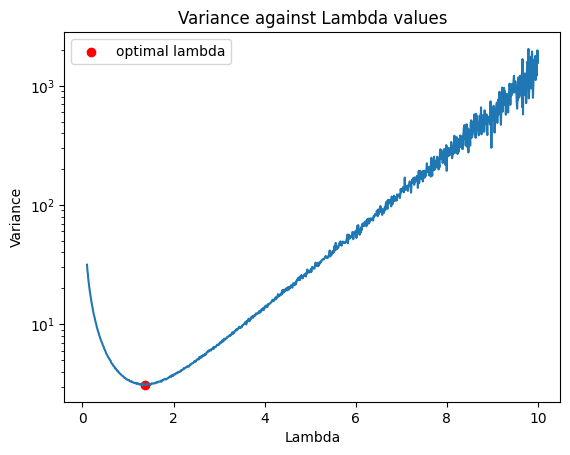

In [21]:
np.random.seed(42)
import matplotlib.pyplot as plt

n_is_samples = 100000

lambdas = np.linspace(0.1,10,1000)

means = []
vars = []

for lam in lambdas:    
    # 2. Simulation
    x_is = np.random.exponential(1/lam,n_is_samples)
    h = np.exp(x_is)
    g = lam*np.exp(-lam*x_is)
    
    estimates = np.where(x_is <= 1.0, h/g, 0)
    means.append(np.mean(estimates))
    vars.append(np.var(estimates,ddof=1))

best = lambdas[np.argmin(vars)]
print(best)
print(np.min(vars))


plt.semilogy(lambdas,vars)
plt.scatter(best, np.min(vars), label='optimal lambda', c='r' )
plt.xlabel('Lambda')
plt.ylabel('Variance')
plt.title('Variance against Lambda values')
plt.legend()
plt.plot()

In [10]:
np.argmin(vars)

np.int64(129)

## Ex 6

### Part 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import factorial

np.random.seed(42)

m = 10
A = 8.0
n_samples = 10000
burn_in = 1000
n_total = n_samples + burn_in


# Metropolis-Hastings Sampling
samples_1d = [0]
for _ in range(n_total):
    current = samples_1d[-1]
    
    # Random walk proposal
    proposal = current + np.random.choice([-1, 1],p=[0.5,0.5])
    
    if 0 <= proposal <= m:
        # Acceptance probability
        p_current = (A**current) / factorial(current)
        p_proposal = (A**proposal) / factorial(proposal)
        alpha = min(1.0, p_proposal / p_current)
        
        if np.random.rand() < alpha:
            samples_1d.append(proposal)
            continue
    
    # Reject and stay in current state
    samples_1d.append(current)

# Exact theoretical distribution
i_vals = np.arange(m + 1)
exact_probs = (A**i_vals) / factorial(i_vals)
exact_probs /= np.sum(exact_probs) # Normalize to sum to 1


# Discard the burn-in period (removes the initial state [0] and the first 1,000 steps)
samples_1d_clean = samples_1d[burn_in + 1:]

# Thin the clean samples (e.g., keep every 10th sample to remove autocorrelation)
samples_1d_thinned = samples_1d_clean[::10]

# 3. Chi-Square Verification (using the thinned samples)
obs_counts = np.bincount(samples_1d_thinned, minlength=m+1)
exp_counts = exact_probs * len(samples_1d_thinned)

# Normalize expected frequencies to match the thinned observation count exactly
exp_counts = exp_counts * (np.sum(obs_counts) / np.sum(exp_counts))

chi2, p_val = stats.chisquare(f_obs=obs_counts, f_exp=exp_counts)

print(f"Chi-square statistic (Thinned): {chi2:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("Test passed: The thinned MH sample distribution matches the theoretical distribution.\n")

plt.figure(figsize=(8,4))
# Make sure your plot uses the thinned data size for normalization
plt.bar(i_vals - 0.2, obs_counts/len(samples_1d_thinned), width=0.4, label='MH Samples (Thinned)')
plt.bar(i_vals + 0.2, exact_probs, width=0.4, label='Exact PDF')
plt.title("Erlang System (MH vs Exact)")
plt.legend()
plt.show()


### Part 2

In [ ]:
np.random.seed(42)
A1, A2 = 4.0, 4.0
m = 10
n_samples = 10000
burn_in = 1000
n_total = n_samples + burn_in
thin = 20

# 1. Exact 2D Distribution (for Chi-square tests)
exact_2d = np.zeros((m+1, m+1))
for i in range(m+1):
    for j in range(m+1):
        if i + j <= m:
            exact_2d[i, j] = (A1**i / factorial(i)) * (A2**j / factorial(j))
exact_2d /= np.sum(exact_2d)

def unroll_for_chi2(samples):
    """Helper to convert 2D samples into 1D bins for Chi2 testing."""
    obs_2d = np.zeros((m+1, m+1))
    for i, j in samples:
        obs_2d[i, j] += 1
    
    # Flatten and keep only valid states (i+j <= m)
    valid_mask = exact_2d > 0
    obs_flat = obs_2d[valid_mask]
    exp_flat = exact_2d[valid_mask] * len(samples)
    
    # Filter out small bins (expected count <= 5)
    valid_bins = exp_flat > 5
    
    f_obs = obs_flat[valid_bins]
    f_exp = exp_flat[valid_bins]
    
    # RESCALE: Normalize expected counts to match the observed sum exactly
    f_exp = f_exp * (np.sum(f_obs) / np.sum(f_exp))
    
    return stats.chisquare(f_obs, f_exp)

# --- (a) Direct MH ---
samples_a_raw = [(0, 0)]
for _ in range(n_total):
    i, j = samples_a_raw[-1]
    prop_i, prop_j = i + np.random.choice([-1, 0, 1]), j + np.random.choice([-1, 0, 1])
    
    if prop_i >= 0 and prop_j >= 0 and prop_i + prop_j <= m:
        p_curr = (A1**i / factorial(i)) * (A2**j / factorial(j))
        p_prop = (A1**prop_i / factorial(prop_i)) * (A2**prop_j / factorial(prop_j))
        if np.random.rand() < min(1.0, p_prop / p_curr):
            samples_a_raw.append((prop_i, prop_j))
            continue
    samples_a_raw.append((i, j))

# Slice to get exactly 10,000 post-burn-in samples
samples_a = samples_a_raw[burn_in + 1:]

# --- (b) Coordinate-wise MH ---
samples_b_raw = [(0, 0)]
for _ in range(n_total):
    i, j = samples_b_raw[-1]
    
    # Update i
    prop_i = i + np.random.choice([-1, 1])
    if 0 <= prop_i <= m - j:
        p_curr = A1**i / factorial(i)
        p_prop = A1**prop_i / factorial(prop_i)
        if np.random.rand() < min(1.0, p_prop / p_curr):
            i = prop_i
            
    # Update j
    prop_j = j + np.random.choice([-1, 1])
    if 0 <= prop_j <= m - i:
        p_curr = A2**j / factorial(j)
        p_prop = A2**prop_j / factorial(prop_j)
        if np.random.rand() < min(1.0, p_prop / p_curr):
            j = prop_j
            
    samples_b_raw.append((i, j))

# Slice to get exactly 10,000 post-burn-in samples
samples_b = samples_b_raw[burn_in + 1:]

# --- (c) Gibbs Sampling ---
samples_c_raw = [(0, 0)]
for _ in range(n_total):
    i, j = samples_c_raw[-1]
    
    # Sample i given j (Truncated Poisson)
    max_i = m - j
    i_vals = np.arange(max_i + 1)
    probs_i = (A1**i_vals) / factorial(i_vals)
    i = np.random.choice(i_vals, p=probs_i / np.sum(probs_i))
    
    # Sample j given i (Truncated Poisson)
    max_j = m - i
    j_vals = np.arange(max_j + 1)
    probs_j = (A2**j_vals) / factorial(j_vals)
    j = np.random.choice(j_vals, p=probs_j / np.sum(probs_j))
    
    samples_c_raw.append((i, j))

# Slice to get exactly 10,000 post-burn-in samples
samples_c = samples_c_raw[burn_in + 1:]

# Thinning for Chi-square testing
samples_a_thinned = samples_a[::thin]
samples_b_thinned = samples_b[::thin]
samples_c_thinned = samples_c[::thin]

# Execute the tests using the thinned samples
chi2_a, p_a = unroll_for_chi2(samples_a_thinned)
chi2_b, p_b = unroll_for_chi2(samples_b_thinned)
chi2_c, p_c = unroll_for_chi2(samples_c_thinned)

print(f"(a) Direct MH (Thinned)      - Chi2: {chi2_a:.2f}, p-value: {p_a:.4f}")
print(f"(b) Coord-wise MH (Thinned)  - Chi2: {chi2_b:.2f}, p-value: {p_b:.4f}")
print(f"(c) Gibbs Sampler (Thinned)  - Chi2: {chi2_c:.2f}, p-value: {p_c:.4f}")


### Part 3

In [ ]:
np.random.seed(42)
# (a) Generate prior parameter pair
rho = 0.5
cov_matrix = np.array([[1.0, rho], [rho, 1.0]])
xi_true, gamma_true = np.random.multivariate_normal([0.0, 0.0], cov_matrix)
theta_true, psi_true = np.exp(xi_true), np.exp(gamma_true)

print(f"True (Prior-Drawn) Theta: {theta_true:.4f}, Psi: {psi_true:.4f}\n")

# (b) Generate the observed samples for varying n
n_vals = [10, 100, 1000]
datasets = {n: np.random.normal(theta_true, np.sqrt(psi_true), n) for n in n_vals}

# (c) Define Posterior Components
def log_prior(xi, gamma):
    """Log of the standard bivariate normal prior on (Xi, Gamma)"""
    return -0.5 / (1 - rho**2) * (xi**2 - 2*rho*xi*gamma + gamma**2)

def log_likelihood(X, theta, psi):
    """Log-likelihood simplified using sample mean and variance"""
    n = len(X)
    X_bar = np.mean(X)
    S2 = np.var(X, ddof=1) if n > 1 else 0
    sum_sq = (n - 1) * S2 + n * (X_bar - theta)**2
    return -0.5 * n * np.log(psi) - 0.5 * sum_sq / psi

# (d) Metropolis-Hastings Algorithm over the log-space
def mh_posterior(X, n_iter=10000):
    chain_xi_gamma = [np.array([0.0, 0.0])] # Start guess at (0,0) in log space
    accepted = 0
    
    for _ in range(n_iter):
        curr_xi, curr_gamma = chain_xi_gamma[-1]
        curr_theta, curr_psi = np.exp(curr_xi), np.exp(curr_gamma)
        
        # Random walk proposal in log space
        step_size = 1 / np.sqrt(len(X)) 
        prop_xi, prop_gamma = chain_xi_gamma[-1] + np.random.normal(0, step_size, 2)
        prop_theta, prop_psi = np.exp(prop_xi), np.exp(prop_gamma)
        
        # Calculate Log-Posterior = Log-Likelihood + Log-Prior
        log_p_curr = log_likelihood(X, curr_theta, curr_psi) + log_prior(curr_xi, curr_gamma)
        log_p_prop = log_likelihood(X, prop_theta, prop_psi) + log_prior(prop_xi, prop_gamma)
        
        # Accept/Reject
        if np.log(np.random.rand()) < log_p_prop - log_p_curr:
            chain_xi_gamma.append(np.array([prop_xi, prop_gamma]))
            accepted += 1
        else:
            chain_xi_gamma.append(chain_xi_gamma[-1])
            
    # Discard burn-in and transform back to (Theta, Psi)
    burn_in = 5000
    chain = np.exp(np.array(chain_xi_gamma)[burn_in:])
    return chain, accepted / n_iter
# (e) Execute for n=10, 100, 1000 and plot results separately
for n in n_vals:
    print(f"Running MCMC for n = {n}...")
    chain, acc_rate = mh_posterior(datasets[n])
    
    theta_est = np.mean(chain[:, 0])
    psi_est = np.mean(chain[:, 1])
    print(f"Estimated Theta: {theta_est:.4f}")
    print(f"Estimated Psi:   {psi_est:.4f}")
    print(f"Acceptance Rate: {acc_rate:.2f}")
    
    # 1. Create a 2D joint distribution plot
    plt.figure(figsize=(6, 5))
    plt.scatter(chain[:, 0], chain[:, 1], alpha=0.1, s=1, color='blue', label='Posterior Samples')
    plt.plot(theta_true, psi_true, 'ro', markersize=10, label='True Parameter')
    plt.plot(theta_est, psi_est, 'kx', markersize=10, label='Posterior Mean')
    plt.title(f"Posterior Joint Distribution for n={n} (Acc Rate: {acc_rate:.2f})")
    plt.xlabel("Theta")
    plt.ylabel("Psi")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # 2. Create 1D trace plots side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # x-axis represents the post-burn-in iteration indices (5000 to 20000)
    iterations = np.arange(len(chain)) + 5000 
    
    # Trace plot for Theta
    axes[0].plot(iterations, chain[:, 0], color='teal', alpha=0.6, lw=0.5)
    axes[0].axhline(theta_true, color='red', linestyle='--', label='True Theta')
    axes[0].axhline(theta_est, color='black', linestyle=':', label='Posterior Mean')
    axes[0].set_title(f"Trace Plot for Theta (n={n})")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Theta")
    axes[0].legend()
    
    # Trace plot for Psi
    axes[1].plot(iterations, chain[:, 1], color='orange', alpha=0.6, lw=0.5)
    axes[1].axhline(psi_true, color='red', linestyle='--', label='True Psi')
    axes[1].axhline(psi_est, color='black', linestyle=':', label='Posterior Mean')
    axes[1].set_title(f"Trace Plot for Psi (n={n})")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Psi")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    print("-" * 75)
